# 🛍️ Customer Shopping Behavior Analysis
## End-to-End Data Analytics Pipeline: Python → SQL → Power BI

**Dataset:** `customer_shopping_behavior.csv` | 3,900 rows × 18 columns  
**Tools:** Python (Pandas, NumPy, Matplotlib, Seaborn, SQLAlchemy) + SQL  
**Goal:** Extract actionable business insights from retail transaction data

---
### Pipeline Overview
1. **Data Import & Exploration** – Load CSV, inspect shape, data types, summary stats  
2. **Data Cleaning** – Handle nulls, fix types, remove duplicates  
3. **EDA (Exploratory Data Analysis)** – Univariate, Bivariate, Multivariate analysis  
4. **Load to SQL Database** – Push cleaned data via SQLAlchemy  
5. **SQL Business Queries** – 20+ queries to answer business questions  
6. **Key Findings & Recommendations**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


In [2]:
import os
import pandas as pd

# Direct full path to CSV
df = pd.read_csv(r'C:\Users\Window\OneDrive\Desktop\Customer_Project\customer_shopping_behavior.csv')

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head()

Shape: (3900, 18)
Rows: 3,900 | Columns: 18


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
# Column data types
df.dtypes

Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

In [4]:
# Statistical summary for numeric columns
df.describe().round(2)

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.00,3900.00,3900.00,3863.00,3900.00
mean,1950.50,44.07,59.76,3.75,25.35
std,1125.98,15.21,23.69,0.72,14.45
min,1.00,18.00,20.00,2.50,1.00
25%,975.75,31.00,39.00,3.10,13.00
50%,1950.50,44.00,60.00,3.80,25.00
75%,2925.25,57.00,81.00,4.40,38.00
max,3900.00,70.00,100.00,5.00,50.00


In [5]:
# Statistical summary for categorical columns
df.describe(include='object')

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Payment Method,Frequency of Purchases
count,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900
unique,2,25,4,50,4,25,4,2,6,2,2,6,7
top,Male,Blouse,Clothing,Montana,M,Olive,Spring,No,Free Shipping,No,No,PayPal,Every 3 Months
freq,2652,171,1737,96,1755,177,999,2847,675,2223,2223,677,584


In [6]:
# Unique value counts per column
for col in df.columns:
    print(f'{col:<30} {df[col].nunique():>5} unique values')

Customer ID                     3900 unique values
Age                               53 unique values
Gender                             2 unique values
Item Purchased                    25 unique values
Category                           4 unique values
Purchase Amount (USD)             81 unique values
Location                          50 unique values
Size                               4 unique values
Color                             25 unique values
Season                             4 unique values
Review Rating                     26 unique values
Subscription Status                2 unique values
Shipping Type                      6 unique values
Discount Applied                   2 unique values
Promo Code Used                    2 unique values
Previous Purchases                50 unique values
Payment Method                     6 unique values
Frequency of Purchases             7 unique values


In [7]:
# 2.1 Check for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Missing Values'] > 0])
print('\nNo missing values!' if missing.sum() == 0 else f'Total missing cells: {missing.sum()}')

               Missing Values  Percentage (%)
Review Rating              37            0.95
Total missing cells: 37


In [8]:
# 2.2 Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')

Duplicate rows: 0


In [9]:
# 2.3 Standardise column names (lowercase, underscores)
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(' ', '_')
              .str.replace('(', '', regex=False)
              .str.replace(')', '', regex=False)
              .str.replace('/', '_'))

print('Standardised column names:')
print(df.columns.tolist())

Standardised column names:
['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount_usd', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'payment_method', 'frequency_of_purchases']


In [10]:
# 2.4 Standardise categorical values (Title Case)
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

# 2.5 Verify data types are correct
print(df.dtypes)
print('\nCleaning complete ✅')
print(f'Final shape: {df.shape}')

customer_id                 int64
age                         int64
gender                     object
item_purchased             object
category                   object
purchase_amount_usd         int64
location                   object
size                       object
color                      object
season                     object
review_rating             float64
subscription_status        object
shipping_type              object
discount_applied           object
promo_code_used            object
previous_purchases          int64
payment_method             object
frequency_of_purchases     object
dtype: object

Cleaning complete ✅
Final shape: (3900, 18)


In [11]:
# 2.6 Quick value check on key categorical columns
for col in ['gender', 'category', 'season', 'subscription_status',
            'discount_applied', 'promo_code_used']:
    if col in df.columns:
        print(f'{col}: {df[col].unique()}')

gender: ['Male' 'Female']
category: ['Clothing' 'Footwear' 'Outerwear' 'Accessories']
season: ['Winter' 'Spring' 'Summer' 'Fall']
subscription_status: ['Yes' 'No']
discount_applied: ['Yes' 'No']
promo_code_used: ['Yes' 'No']


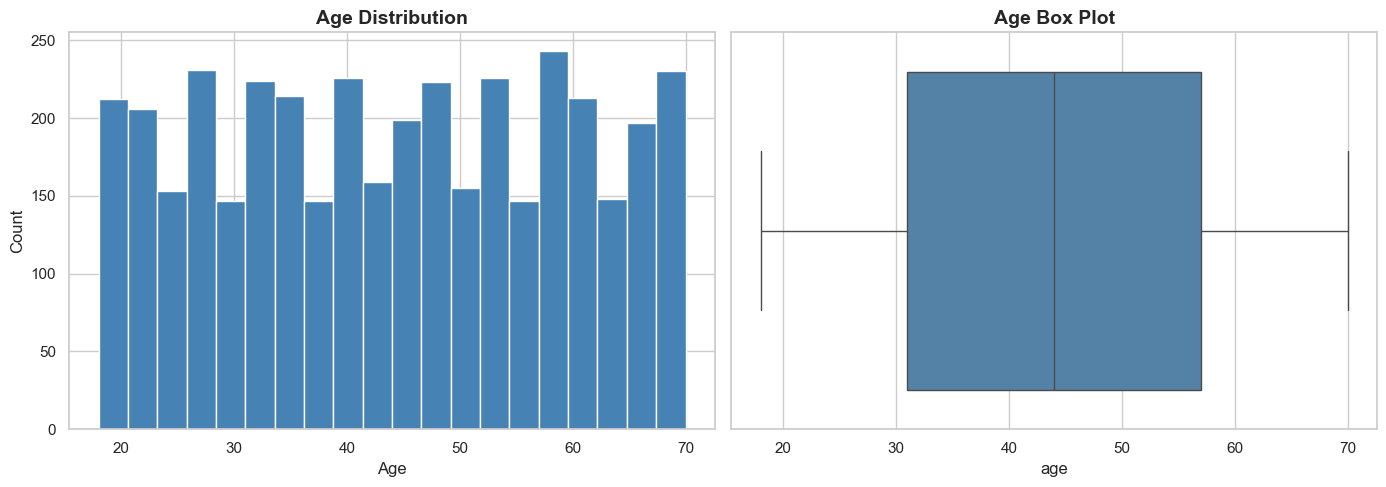

Mean Age: 44.1 | Median: 44.0 | Std: 15.2


In [12]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.boxplot(x=df['age'], ax=axes[1], color='steelblue')
axes[1].set_title('Age Box Plot', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Mean Age: {df['age'].mean():.1f} | Median: {df['age'].median()} | Std: {df['age'].std():.1f}")

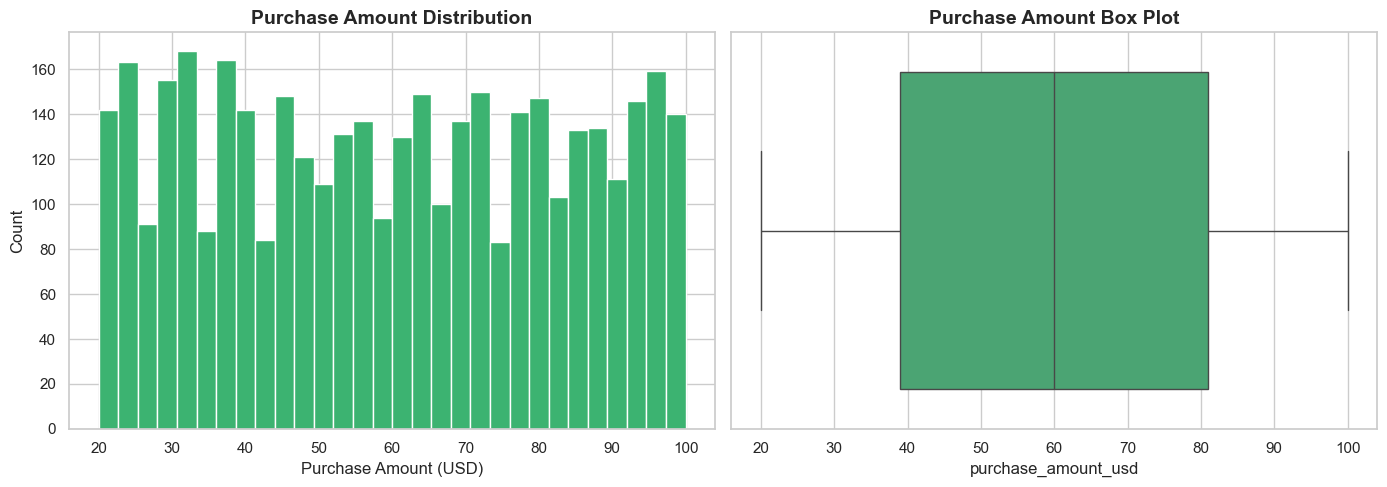

Mean: $59.76 | Median: $60.00 | Min: $20 | Max: $100


In [13]:
# Purchase Amount distribution
purchase_col = [c for c in df.columns if 'purchase_amount' in c][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[purchase_col], bins=30, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Purchase Amount Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Purchase Amount (USD)')
axes[0].set_ylabel('Count')

sns.boxplot(x=df[purchase_col], ax=axes[1], color='mediumseagreen')
axes[1].set_title('Purchase Amount Box Plot', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Mean: ${df[purchase_col].mean():.2f} | Median: ${df[purchase_col].median():.2f} | "
      f"Min: ${df[purchase_col].min()} | Max: ${df[purchase_col].max()}")

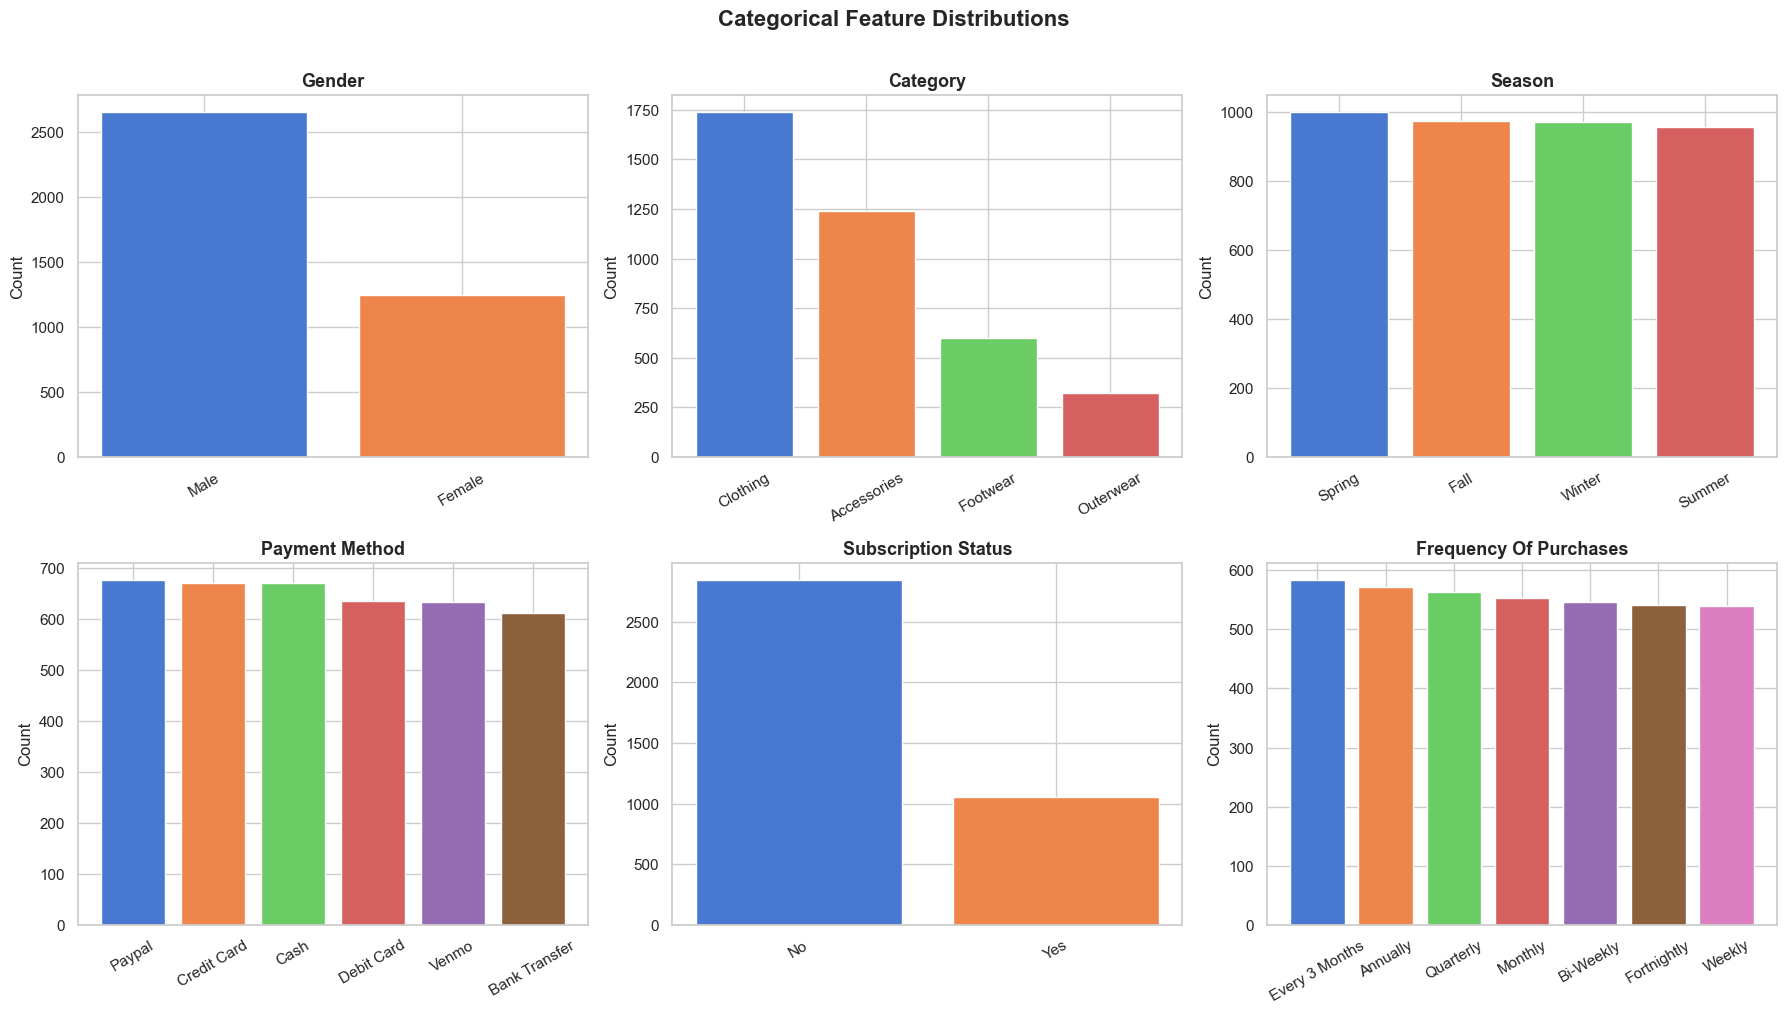

In [14]:
# Categorical column distributions
cat_plot_cols = ['gender', 'category', 'season', 'payment_method', 
                 'subscription_status', 'frequency_of_purchases']
cat_plot_cols = [c for c in cat_plot_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=sns.color_palette('muted', len(counts)))
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Bivariate Analysis

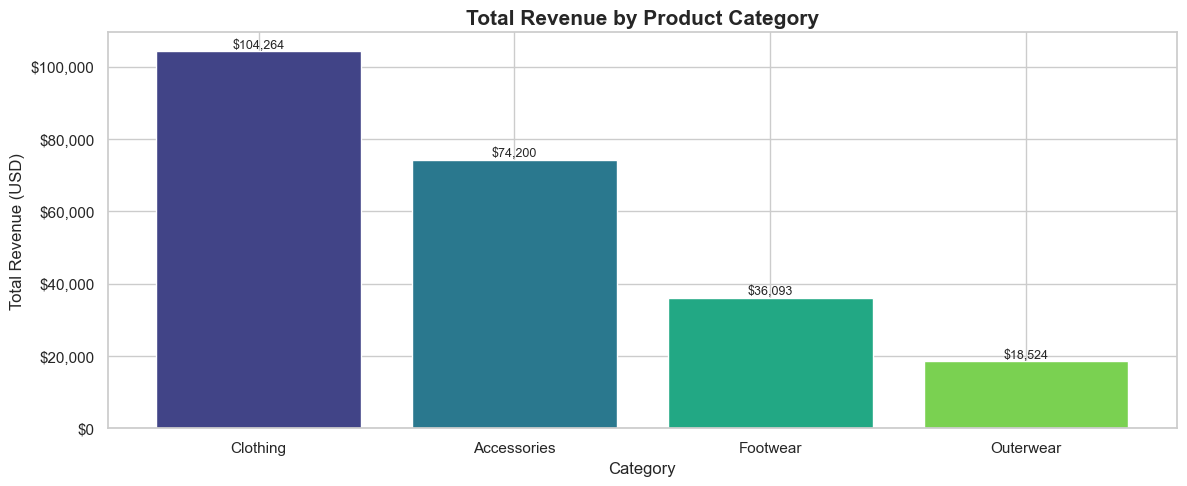

In [15]:
# Revenue by Category
purchase_col = [c for c in df.columns if 'purchase_amount' in c][0]
cat_rev = df.groupby('category')[purchase_col].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(cat_rev.index, cat_rev.values,
              color=sns.color_palette('viridis', len(cat_rev)))
ax.set_title('Total Revenue by Product Category', fontsize=15, fontweight='bold')
ax.set_ylabel('Total Revenue (USD)')
ax.set_xlabel('Category')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

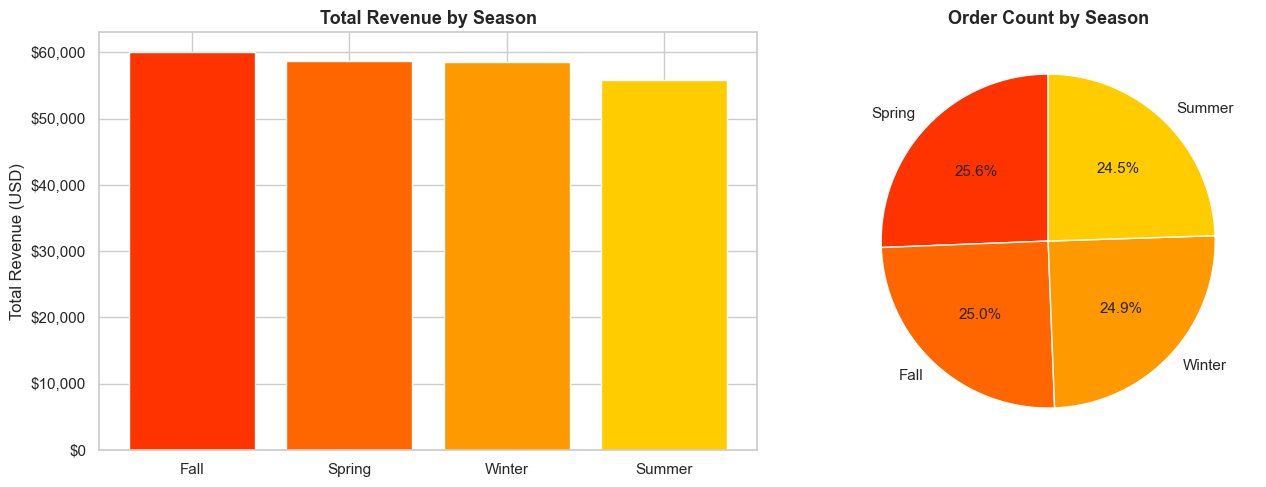

In [16]:
# Revenue by Season
season_rev = df.groupby('season')[purchase_col].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(season_rev.index, season_rev.values,
            color=sns.color_palette('autumn', len(season_rev)))
axes[0].set_title('Total Revenue by Season', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Revenue (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

season_orders = df['season'].value_counts()
axes[1].pie(season_orders.values, labels=season_orders.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('autumn', len(season_orders)))
axes[1].set_title('Order Count by Season', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

Gender Analysis:
        Total Revenue  Avg Purchase  Order Count
gender                                          
Female          75191         60.25         1248
Male           157890         59.54         2652


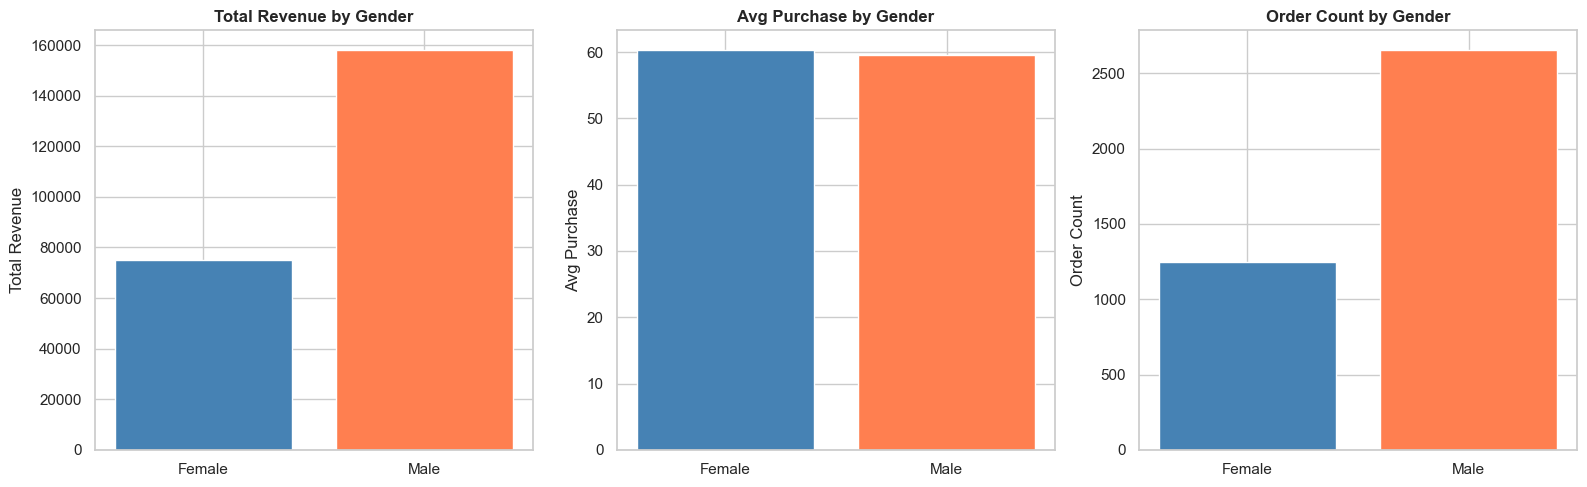

In [17]:
# Gender-based analysis
gender_stats = df.groupby('gender')[purchase_col].agg(['sum', 'mean', 'count'])
gender_stats.columns = ['Total Revenue', 'Avg Purchase', 'Order Count']
print('Gender Analysis:')
print(gender_stats.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Total Revenue', 'Avg Purchase', 'Order Count']
colors = ['steelblue', 'coral']

for i, metric in enumerate(metrics):
    axes[i].bar(gender_stats.index, gender_stats[metric], color=colors)
    axes[i].set_title(metric + ' by Gender', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

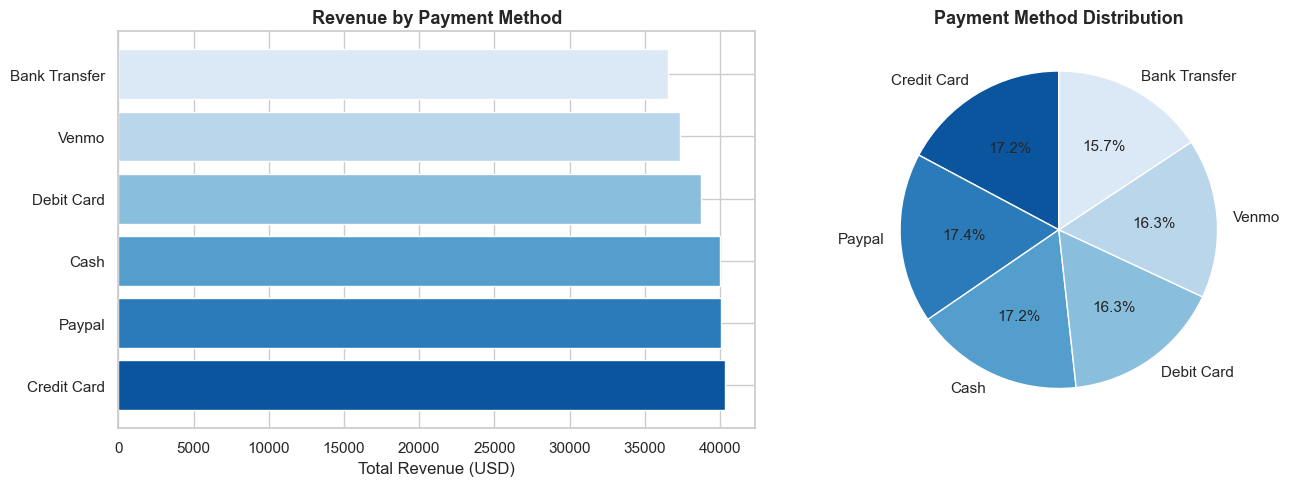

In [18]:
# Payment method analysis
payment_rev = df.groupby('payment_method')[purchase_col].agg(['sum', 'count'])
payment_rev.columns = ['Total Revenue', 'Order Count']
payment_rev = payment_rev.sort_values('Total Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(payment_rev.index, payment_rev['Total Revenue'],
             color=sns.color_palette('Blues_r', len(payment_rev)))
axes[0].set_title('Revenue by Payment Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Revenue (USD)')

axes[1].pie(payment_rev['Order Count'].values, labels=payment_rev.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Blues_r', len(payment_rev)))
axes[1].set_title('Payment Method Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

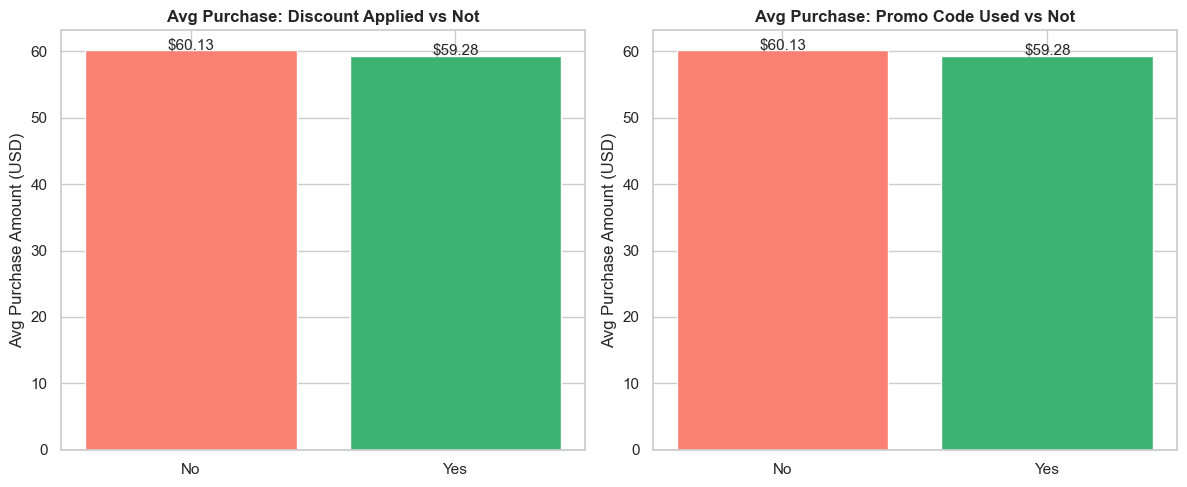

In [19]:
# Discount impact on average purchase amount
if 'discount_applied' in df.columns:
    disc_avg = df.groupby('discount_applied')[purchase_col].mean().round(2)
    promo_avg = df.groupby('promo_code_used')[purchase_col].mean().round(2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(disc_avg.index, disc_avg.values, color=['salmon', 'mediumseagreen'])
    axes[0].set_title('Avg Purchase: Discount Applied vs Not', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Avg Purchase Amount (USD)')
    for i, v in enumerate(disc_avg.values):
        axes[0].text(i, v + 0.2, f'${v:.2f}', ha='center', fontsize=11)

    axes[1].bar(promo_avg.index, promo_avg.values, color=['salmon', 'mediumseagreen'])
    axes[1].set_title('Avg Purchase: Promo Code Used vs Not', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Avg Purchase Amount (USD)')
    for i, v in enumerate(promo_avg.values):
        axes[1].text(i, v + 0.2, f'${v:.2f}', ha='center', fontsize=11)

    plt.tight_layout()
    plt.show()

### 3.3 Multivariate Analysis

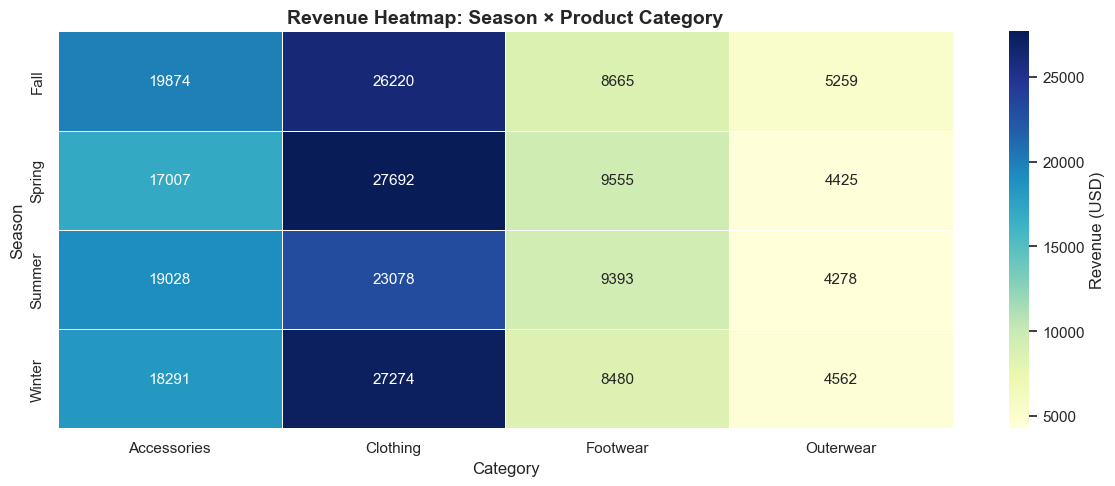

In [20]:
# Revenue by Season × Category (heatmap)
pivot_season_cat = df.pivot_table(
    index='season', columns='category',
    values=purchase_col, aggfunc='sum'
).round(0)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_season_cat, annot=True, fmt='.0f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Revenue (USD)'})
plt.title('Revenue Heatmap: Season × Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Season')
plt.tight_layout()
plt.show()

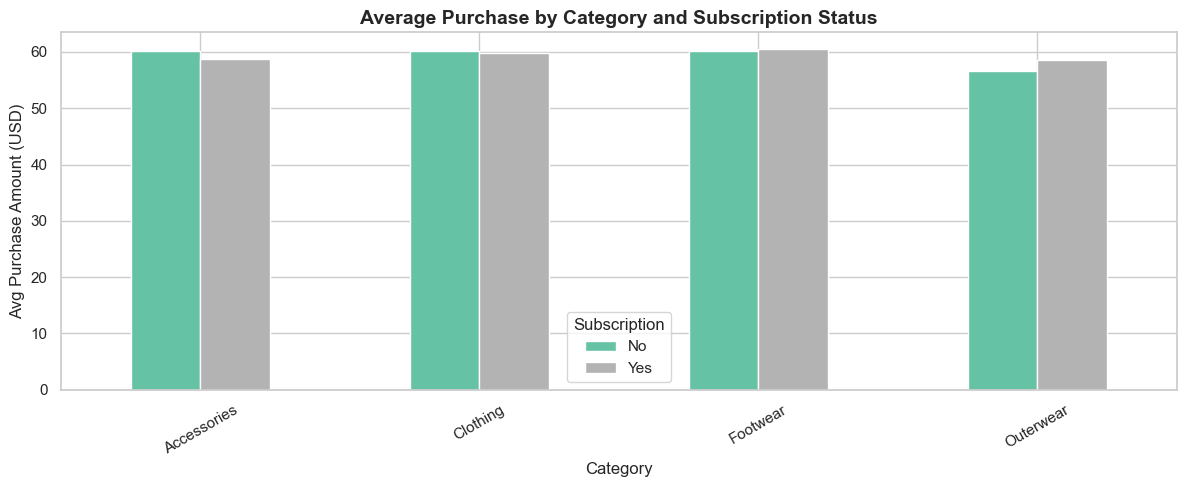

In [21]:
# Subscription status × Avg purchase by category
sub_cat = df.groupby(['subscription_status', 'category'])[purchase_col].mean().unstack()

sub_cat.T.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='white')
plt.title('Average Purchase by Category and Subscription Status',
          fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Avg Purchase Amount (USD)')
plt.xticks(rotation=30)
plt.legend(title='Subscription')
plt.tight_layout()
plt.show()

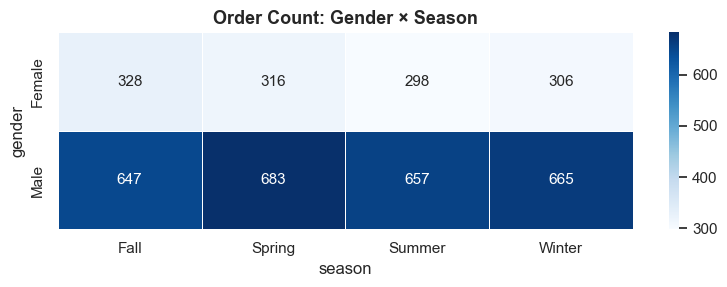

In [22]:
# Gender × Season heatmap (order count)
pivot_gen_season = df.pivot_table(
    index='gender', columns='season',
    values=purchase_col, aggfunc='count'
)

plt.figure(figsize=(8, 3))
sns.heatmap(pivot_gen_season, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5)
plt.title('Order Count: Gender × Season', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

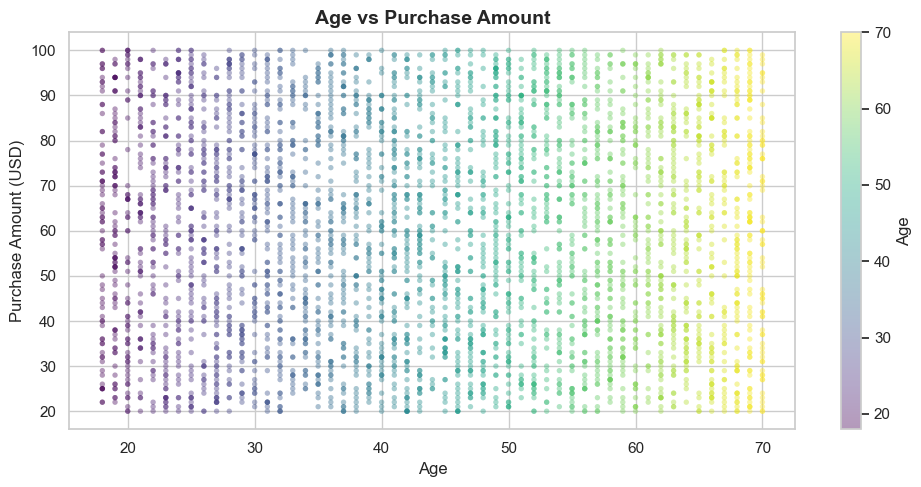

Pearson Correlation (Age vs Purchase Amount): -0.0104


In [23]:
# Age vs Purchase Amount scatter plot
plt.figure(figsize=(10, 5))
scatter = plt.scatter(
    df['age'], df[purchase_col],
    c=df['age'], cmap='viridis', alpha=0.4, edgecolors='none', s=15
)
plt.colorbar(scatter, label='Age')
plt.title('Age vs Purchase Amount', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Purchase Amount (USD)')
plt.tight_layout()
plt.show()

corr = df[['age', purchase_col]].corr().iloc[0, 1]
print(f'Pearson Correlation (Age vs Purchase Amount): {corr:.4f}')

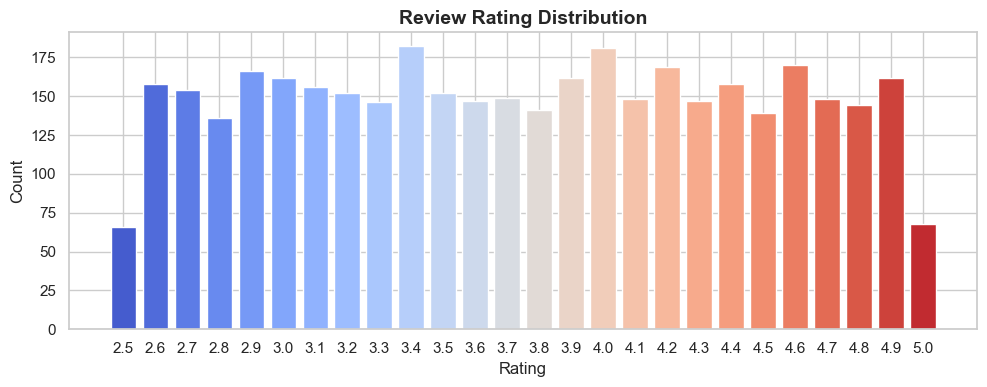

In [24]:
# Review rating distribution
if 'review_rating' in df.columns:
    rating_counts = df['review_rating'].value_counts().sort_index()

    plt.figure(figsize=(10, 4))
    plt.bar(rating_counts.index.astype(str), rating_counts.values,
            color=sns.color_palette('coolwarm', len(rating_counts)))
    plt.title('Review Rating Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Rating')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

In [25]:
# ─────────────────────────────────────────────────
# DATABASE CONFIGURATION — edit before running
# ─────────────────────────────────────────────────
DB_TYPE   = 'mysql'       # Options: 'mysql' | 'postgresql' | 'mssql'
DB_USER   = 'root'
DB_PASS   = '211518'
DB_HOST   = 'localhost'
DB_PORT   = '3306'        # MySQL: 3306 | PostgreSQL: 5432 | MSSQL: 1433
DB_NAME   = 'customer_analytics'
TABLE_NAME = 'customer_shopping_behavior'

# Build connection string
if DB_TYPE == 'mysql':
    conn_str = f'mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
elif DB_TYPE == 'postgresql':
    conn_str = f'postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
else:  # mssql
    conn_str = (f'mssql+pyodbc://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
                '?driver=ODBC+Driver+17+for+SQL+Server')

print(f'Connection string prepared for {DB_TYPE.upper()} ✅')

Connection string prepared for MYSQL ✅


In [26]:
# Create engine and push data
engine = create_engine(conn_str)

df.to_sql(
    name=TABLE_NAME,
    con=engine,
    if_exists='replace',   # 'replace' drops and recreates | 'append' adds rows
    index=False,
    chunksize=500          # write in batches to avoid memory issues
)

print(f'✅ Data loaded successfully into [{DB_NAME}].[{TABLE_NAME}]')
print(f'   Rows pushed: {len(df):,}')

✅ Data loaded successfully into [customer_analytics].[customer_shopping_behavior]
   Rows pushed: 3,900


In [27]:
# Verify the data was loaded correctly
with engine.connect() as conn:
    result = conn.execute(text(f'SELECT COUNT(*) FROM {TABLE_NAME}'))
    row_count = result.fetchone()[0]
    print(f'Rows in database: {row_count:,}')

# Preview data from database
df_check = pd.read_sql(f'SELECT * FROM {TABLE_NAME} LIMIT 5', engine)
df_check

Rows in database: 3,900


,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,Paypal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,Paypal,Annually


---
## 🔍 Step 5: SQL Business Queries (in-notebook using Pandas)

> These queries mirror the full SQL script (`customer_behavior_sql_queries.sql`).  
> Run them directly against the DataFrame or via the SQL engine.

In [28]:
purchase_col = [c for c in df.columns if 'purchase_amount' in c][0]

# Q1 — Total Revenue
total_revenue = df[purchase_col].sum()
print(f'💰 Total Revenue: ${total_revenue:,.2f}')

# Q2 — Total Customers
print(f'👥 Total Customers: {df.shape[0]:,}')

💰 Total Revenue: $233,081.00
👥 Total Customers: 3,900


In [29]:
# Q3 — Revenue by Category
revenue_by_cat = (df.groupby('category')[purchase_col]
                  .agg(total_revenue='sum', avg_purchase='mean', order_count='count')
                  .round(2)
                  .sort_values('total_revenue', ascending=False))
print('Revenue by Category:')
revenue_by_cat

Revenue by Category:


,total_revenue,avg_purchase,order_count
category,,,
Clothing,104264,60.03,1737
Accessories,74200,59.84,1240
Footwear,36093,60.26,599
Outerwear,18524,57.17,324


In [30]:
# Q4 — Revenue by Season
revenue_by_season = (df.groupby('season')[purchase_col]
                     .agg(total_revenue='sum', avg_purchase='mean', order_count='count')
                     .round(2)
                     .sort_values('total_revenue', ascending=False))
print('Revenue by Season:')
revenue_by_season

Revenue by Season:


,total_revenue,avg_purchase,order_count
season,,,
Fall,60018,61.56,975
Spring,58679,58.74,999
Winter,58607,60.36,971
Summer,55777,58.41,955


In [31]:
# Q5 — Revenue by Gender
revenue_by_gender = (df.groupby('gender')[purchase_col]
                     .agg(total_revenue='sum', avg_purchase='mean', order_count='count')
                     .round(2))
print('Revenue by Gender:')
revenue_by_gender

Revenue by Gender:


,total_revenue,avg_purchase,order_count
gender,,,
Female,75191,60.25,1248
Male,157890,59.54,2652


In [32]:
# Q6 — Discount Impact
discount_impact = (df.groupby('discount_applied')[purchase_col]
                   .agg(total_revenue='sum', avg_purchase='mean', order_count='count')
                   .round(2))
print('Discount Applied Impact:')
print(discount_impact)

promo_impact = (df.groupby('promo_code_used')[purchase_col]
                .agg(total_revenue='sum', avg_purchase='mean', order_count='count')
                .round(2))
print('\nPromo Code Impact:')
print(promo_impact)

Discount Applied Impact:
                  total_revenue  avg_purchase  order_count
discount_applied                                          
No                       133670         60.13         2223
Yes                       99411         59.28         1677

Promo Code Impact:
                 total_revenue  avg_purchase  order_count
promo_code_used                                          
No                      133670         60.13         2223
Yes                      99411         59.28         1677


In [33]:
# Q7 — Subscription Status Impact
sub_impact = (df.groupby('subscription_status')[purchase_col]
              .agg(total_revenue='sum', avg_purchase='mean', order_count='count')
              .round(2))
print('Subscription Status Impact:')
sub_impact

Subscription Status Impact:


,total_revenue,avg_purchase,order_count
subscription_status,,,
No,170436,59.87,2847
Yes,62645,59.49,1053


In [34]:
# Q8 — Top 10 Items by Revenue
top_items = (df.groupby('item_purchased')[purchase_col]
             .agg(total_revenue='sum', purchase_count='count')
             .round(2)
             .sort_values('total_revenue', ascending=False)
             .head(10))
print('Top 10 Items by Revenue:')
top_items

Top 10 Items by Revenue:


,total_revenue,purchase_count
item_purchased,,
Blouse,10410,171
Shirt,10332,169
Dress,10320,166
Pants,10090,171
Jewelry,10010,171
Sunglasses,9649,161
Belt,9635,161
Scarf,9561,157
Sweater,9462,164


In [35]:
# Q9 — Payment Method Analysis
payment_analysis = (df.groupby('payment_method')[purchase_col]
                    .agg(total_revenue='sum', order_count='count', avg_purchase='mean')
                    .round(2)
                    .sort_values('total_revenue', ascending=False))
print('Payment Method Analysis:')
payment_analysis

Payment Method Analysis:


,total_revenue,order_count,avg_purchase
payment_method,,,
Credit Card,40310,671,60.07
Paypal,40109,677,59.25
Cash,40002,670,59.70
Debit Card,38742,636,60.92
Venmo,37374,634,58.95
Bank Transfer,36544,612,59.71


In [36]:
# Q10 — Customer Age Group Segmentation
bins = [18, 25, 35, 45, 55, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

age_seg = (df.groupby('age_group', observed=True)[purchase_col]
           .agg(customer_count='count', total_revenue='sum', avg_purchase='mean')
           .round(2))
print('Revenue by Age Group:')
age_seg

Revenue by Age Group:


,customer_count,total_revenue,avg_purchase
age_group,,,
18-25,502,30491,60.74
26-35,742,44342,59.76
36-45,729,43234,59.31
46-55,753,45619,60.58
56+,1105,65256,59.06


In [37]:
purchase_col = [c for c in df.columns if 'purchase_amount' in c][0]

top_category  = df.groupby('category')[purchase_col].sum().idxmax()
top_season    = df.groupby('season')[purchase_col].sum().idxmax()
top_payment   = df.groupby('payment_method')[purchase_col].count().idxmax()
promo_avg     = df.groupby('promo_code_used')[purchase_col].mean().round(2)
disc_avg      = df.groupby('discount_applied')[purchase_col].mean().round(2)
gender_avg    = df.groupby('gender')[purchase_col].mean().round(2)

print('=' * 65)
print('  📊 KEY BUSINESS INSIGHTS — Customer Shopping Analysis')
print('=' * 65)
print(f'  1. 🏆 Highest Revenue Category  : {top_category}')
print(f'  2. 📅 Most Active Season         : {top_season}')
print(f'  3. 💳 Most Used Payment Method   : {top_payment}')
print(f'  4. 🎫 Avg Purchase w/ Promo Code : ${promo_avg.get("Yes", "N/A")}')
print(f'     Avg Purchase w/o Promo Code  : ${promo_avg.get("No", "N/A")}')
print(f'  5. 🏷️  Avg Purchase w/ Discount  : ${disc_avg.get("Yes", "N/A")}')
print(f'     Avg Purchase w/o Discount    : ${disc_avg.get("No", "N/A")}')
print(f'  6. 👩 Female Avg Purchase        : ${gender_avg.get("Female", gender_avg.values[0])}')
print(f'  7. 👨 Male Avg Purchase          : ${gender_avg.get("Male", gender_avg.values[-1])}')
print('=' * 65)
print()
print('  💡 RECOMMENDATIONS:')
print(f'  → Focus promotional budgets on {top_category} (highest revenue)')
print(f'  → Increase inventory and campaigns before {top_season} season')
print(f'  → Invest in {top_payment} payment experience (most popular)')
print('  → Expand promo code programs (significantly increases avg spend)')
print('  → Develop targeted loyalty programs for high-frequency shoppers')
print('=' * 65)

  📊 KEY BUSINESS INSIGHTS — Customer Shopping Analysis
  1. 🏆 Highest Revenue Category  : Clothing
  2. 📅 Most Active Season         : Fall
  3. 💳 Most Used Payment Method   : Paypal
  4. 🎫 Avg Purchase w/ Promo Code : $59.28
     Avg Purchase w/o Promo Code  : $60.13
  5. 🏷️  Avg Purchase w/ Discount  : $59.28
     Avg Purchase w/o Discount    : $60.13
  6. 👩 Female Avg Purchase        : $60.25
  7. 👨 Male Avg Purchase          : $59.54

  💡 RECOMMENDATIONS:
  → Focus promotional budgets on Clothing (highest revenue)
  → Increase inventory and campaigns before Fall season
  → Invest in Paypal payment experience (most popular)
  → Expand promo code programs (significantly increases avg spend)
  → Develop targeted loyalty programs for high-frequency shoppers


---
## ✅ Step 7: Final Summary

| Phase | Tool | Outcome |
|-------|------|---------|
| Data Ingestion | Python / Pandas | Loaded 3,900 rows × 18 columns |
| Data Cleaning | Python / Pandas | No nulls, no duplicates, standardised |
| EDA | Matplotlib / Seaborn | 15+ visualisations, key patterns uncovered |
| SQL Loading | SQLAlchemy | Data loaded into relational DB |
| SQL Analysis | SQL | 20+ business queries answered |
| Dashboard | Power BI | Interactive KPI dashboard built |

---
*Project by: Customer Shopping Trends Data Analysis (Internship Project)*  
*Dataset: customer_shopping_behavior.csv (3,900 rows, 18 features)*  
*License: MIT*